# L3. Multimodal Memory: Text and Photos

L2's `EdgeShard` API stays the same; L3 adds an image encoder and routes each modality to its own named vector.

## 1. One question: which model for which memory?

## 2. A single shard, two named vectors

In [2]:
from helper import create_memory_shard, search_memories
from helper import count_memories
from helper import NOMIC_DIM, CLIP_DIM

shard = create_memory_shard(
    "./mem_shard", {"text": NOMIC_DIM, "image": CLIP_DIM}
)
print(f"Shard ready with vectors: text ({NOMIC_DIM}-d, "
      f"Nomic), image ({CLIP_DIM}-d, CLIP)")

Shard ready with vectors: text (768-d, Nomic), image (512-d, CLIP)


In [3]:
from helper import routing_diagram
routing_diagram()

memory,model,named vector,
Text notes,Nomic 768-d,text,
memory,model,named vector,
Text notes,Nomic 768-d,text,
Photos,CLIP 512-d,image,new in L3


## 3. Store text notes (Nomic)

In [4]:
from helper import embed_text, add_memories

notes = [
    "Great little coffee place on 5th with outdoor "
    "seating and fast wifi",
    "Standup with Sarah moved to Thursday to review "
    "the Q3 roadmap",
    "Liked the white running shoes at the mall, about $45",
]
add_memories(shard, "text", embed_text(notes),
             [{"kind": "note", "note": n} for n in notes])
print("Stored", len(notes), "text notes")

Stored 3 text notes


## 4. Store photos (CLIP)

In [5]:
import glob, os
from helper import embed_image

files = sorted(glob.glob("../data/images/*.jpg"))
add_memories(
    shard, "image", embed_image(files),
    [{"kind": "photo", "file": os.path.basename(f)}
     for f in files],
    start_id=100,
)
print("Stored", len(files), "photos:",
      [os.path.basename(f) for f in files])
print("Total memories in shard:", count_memories(shard))

Stored 6 photos: ['book.jpg', 'coffee.jpg', 'plant.jpg', 'restaurant.jpg', 'sneakers.jpg', 'street.jpg']
Total memories in shard: 9


## 5. Money output: find a photo by describing it

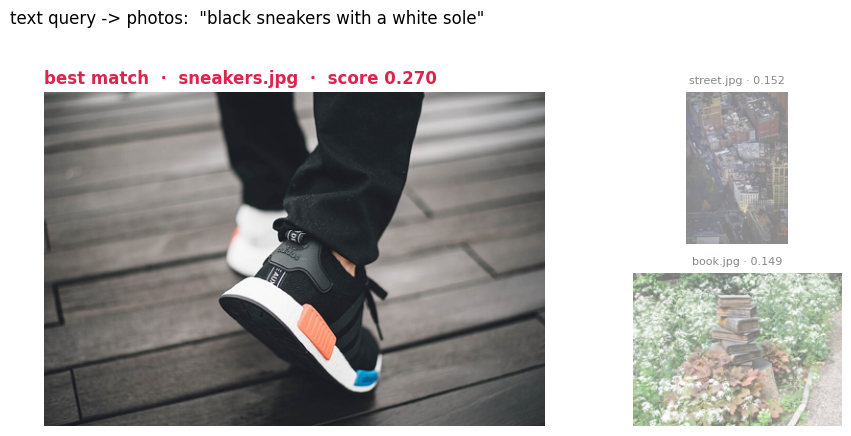

In [6]:
from qdrant_edge import Query, QueryRequest
from helper import embed_text_clip, show_photo_results

query = "black sneakers with a white sole"
photo_hits = shard.query(QueryRequest(
    query=Query.Nearest(embed_text_clip(query), using="image"),
    limit=3, with_payload=True,
))
show_photo_results(photo_hits, "../data/images", query)

## 6. Two spaces, shown side by side: never merged

Query sent to both vectors: "coffee"



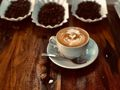

In [7]:
from helper import embed_query, memory_inbox

topic = "coffee"
text_hits = shard.query(QueryRequest(
    query=Query.Nearest(embed_query(topic), using="text"),
    limit=2, with_payload=True,
))
image_hits = shard.query(QueryRequest(
    query=Query.Nearest(embed_text_clip(topic), using="image"),
    limit=1, with_payload=True,
))

print(f'Query sent to both vectors: "{topic}"')
memory_inbox(
    {"Photos": image_hits, "Text Notes": text_hits},
    "../data/images",
)

In [9]:
from helper import cleanup
cleanup(shard, "./mem_shard")
print("Cleaned up")

Cleaned up
